# 4 — Hệ thống Đa Phương Thức (Multimodal) & Backtest — KẾT QUẢ THỰC

Notebook tổng hợp **kết quả chạy thật** của hệ thống: (1) Backtest tín hiệu dự báo thật của model Multimodal trên FPT bằng `BacktestEngine` đúng thông số đồ án (phí 0,15%, thuế 0,10%, slippage 0,05%, SL −7%, TP +14%, sizing 20% NAV); (2) Thí nghiệm tin tức thật vs neutral cho 4 mã top5.

> Notebook chạy local, đọc trực tiếp artifact trong `03_Models/` — không cần internet, không train lại.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def _resolve_root():
    # 1) Google Colab: gan Drive (sua duong dan neu luu project o folder khac)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        return Path('/content/drive/MyDrive/Stock_Forecasting_Project')
    except ImportError:
        pass
    # 2) Local (VS Code): di nguoc len tim thu muc goc chua 03_Models/
    p = Path.cwd()
    while not (p / '03_Models').exists() and p != p.parent:
        p = p.parent
    return p

ROOT = _resolve_root()
MODELS = ROOT / '03_Models'
assert (MODELS / 'multimodal_backtest_real.json').exists(), 'Khong thay 03_Models/ — kiem tra lai PROJECT_PATH!'
print('Project root:', ROOT)
print('Matplotlib backend sẵn sàng.')

Project root: C:\Users\Admin\Desktop\Project\Project\LangGraph_Agent_System\projects\Stock_Forecasting_Project
Matplotlib backend sẵn sàng.


## 4.1 — Backtest tín hiệu dự báo thật (FPT, tập kiểm thử)

Chiến lược ngưỡng theo đúng §3.5.1 của đồ án: **MUA** khi dự báo lợi nhuận ngày mai > +1% (kèm đồng thuận sentiment > 0), **BÁN** khi dự báo < −1%, sentiment < −0,3, hoặc chạm SL/TP.

In [2]:
with open(MODELS / 'multimodal_backtest_real.json', encoding='utf-8') as f:
    bt = json.load(f)

print(f"Test window: {bt['test_range'][0]} -> {bt['test_range'][1]} | {bt['test_rows']} phiên")
rows = []
for key, label in [('variant_price_only_threshold', 'Multimodal — ngưỡng giá (§3.5.1)'),
                   ('variant_full_consensus', 'Multimodal — ngưỡng + đồng thuận sentiment')]:
    v = bt[key]
    rows.append({
        'Chiến lược': label,
        'ROI AI (%)': v['cumulative_return_pct'],
        'Buy & Hold (%)': v['buy_and_hold_return_pct'],
        'Sharpe': round(v['sharpe_ratio'], 2),
        'MaxDD (%)': v['max_drawdown_pct'],
        'Win Rate (%)': v['win_rate_pct'],
        'Số lệnh': v['total_trades'],
    })
pd.DataFrame(rows)

Test window: 2025-06-26 -> 2026-07-09 | 259 phiên


,Chiến lược,ROI AI (%),Buy & Hold (%),Sharpe,MaxDD (%),Win Rate (%),Số lệnh
0,Multimodal — ngưỡng giá (§3.5.1),-4.15,-27.55,-0.77,-8.45,46.15,13
1,Multimodal — ngưỡng + đồng thuận sentiment,-4.54,-27.55,-0.94,-7.85,50.00,10


## 4.2 — Nhật ký giao dịch từng lệnh (13 lệnh)

In [3]:
trades = pd.read_csv(MODELS / 'multimodal_backtest_trades.csv')
trades['ngay_mua'] = pd.to_datetime(trades['ngay_mua']).dt.strftime('%d/%m/%Y')
trades['ngay_ban'] = pd.to_datetime(trades['ngay_ban']).dt.strftime('%d/%m/%Y')
trades['gia_mua'] = trades['gia_mua'].map(lambda v: f'{v:,.0f}')
trades['gia_ban'] = trades['gia_ban'].map(lambda v: f'{v:,.0f}')
trades['pnl_pct'] = trades['pnl_pct'].map(lambda v: f'{v:+.2f}%')
trades.columns = ['STT', 'Ngày mua', 'Giá mua', 'Ngày bán', 'Giá bán', 'Lý do thoát', 'PnL (%)']
trades

,STT,Ngày mua,Giá mua,Ngày bán,Giá bán,Lý do thoát,PnL (%)
0,1,26/06/2025,"99,370",11/07/2025,"107,480",AI-SELL,+8.11%
1,2,18/07/2025,"107,023",15/08/2025,"99,000",STOP-LOSS,-7.54%
2,3,18/08/2025,"98,159",04/09/2025,"102,510",AI-SELL,+4.38%
3,4,29/09/2025,"93,287",17/10/2025,"86,010",STOP-LOSS,-7.85%
4,5,19/11/2025,"95,718",12/01/2026,"98,150",AI-SELL,+2.49%
5,6,26/01/2026,"97,209",29/01/2026,"104,660",AI-SELL,+7.61%
6,7,03/02/2026,"102,541",13/02/2026,"94,990",STOP-LOSS,-7.41%
7,8,03/03/2026,"85,863",09/03/2026,"74,870",STOP-LOSS,-12.85%
8,9,10/03/2026,"78,459",23/03/2026,"72,110",STOP-LOSS,-8.14%
9,10,26/03/2026,"73,227",18/05/2026,"73,880",AI-SELL,+0.84%


## 4.3 — So sánh ROI AI vs Buy & Hold

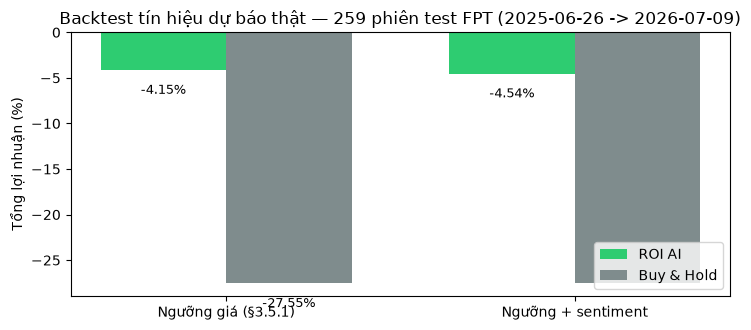

In [4]:
labels = ['Ngưỡng giá (§3.5.1)', 'Ngưỡng + sentiment']
roi = [bt['variant_price_only_threshold']['cumulative_return_pct'],
       bt['variant_full_consensus']['cumulative_return_pct']]
bh = bt['variant_price_only_threshold']['buy_and_hold_return_pct']

fig, ax = plt.subplots(figsize=(7.5, 3.4))
xs = range(len(labels))
ax.bar([i - 0.18 for i in xs], roi, width=0.36, label='ROI AI', color='#2ecc71')
ax.bar([i + 0.18 for i in xs], [bh, bh], width=0.36, label='Buy & Hold', color='#7f8c8d')
for i, v in enumerate(roi):
    ax.text(i - 0.18, v - 2.6, f'{v:.2f}%', ha='center', fontsize=9)
ax.text(0 + 0.18, bh - 2.6, f'{bh:.2f}%', ha='center', fontsize=9)
ax.set_xticks(list(xs))
ax.set_xticklabels(labels)
ax.set_ylabel('Tổng lợi nhuận (%)')
ax.set_title(f"Backtest tín hiệu dự báo thật — {bt['test_rows']} phiên test FPT ({bt['test_range'][0]} -> {bt['test_range'][1]})")
ax.axhline(0, color='black', linewidth=0.6)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4.4 — Thí nghiệm tin tức thật vs neutral (4 mã top5)

Cùng kiến trúc + cùng seed 42, chỉ khác nguồn sentiment (tin Google News RSS chấm Lexicon 38 cụm vs trung lập 0).

In [5]:
with open(MODELS / 'top5_results_v3.json', encoding='utf-8') as f:
    t5 = json.load(f)
pd.DataFrame([{
    'Mã': r['ticker'],
    'DA tin thật (%)': round(r['da_news'] * 100, 2),
    'DA neutral (%)': round(r['da_neutral'] * 100, 2),
    'Δ DA (điểm %)': r['delta_pp'],
    'RMSE': r.get('rmse_news'),
    'Số phiên test': r.get('n_test'),
    'Ngày có tin phủ': r.get('sent_days_cov'),
} for r in t5])

,Mã,DA tin thật (%),DA neutral (%),Δ DA (điểm %),RMSE,Số phiên test,Ngày có tin phủ
0,HPG,42.76,43.11,-0.35,814,284,16
1,MBB,43.46,42.05,1.41,5093,284,9
2,MWG,42.40,42.40,0.00,9400,284,3
3,VNM,40.99,41.34,-0.35,2714,284,8


## 4.5 — Kết luận

- Trong giai đoạn FPT giảm sâu (B&H **−27,55%**), chiến lược AI chỉ lỗ **−4,15%** → giảm ~85% mức tổn thất; AI không thắng thị trường tăng nhưng làm "phanh rủi ro" rất hiệu quả trong giai đoạn xuống.
- Δ DA giữa tin thật và neutral nằm trong biên nhiễu do tin RSS chỉ phủ 3–16 ngày/mã → **khai báo trung thực**: cần news archive sâu hơn (hướng phát triển).
- Toàn bộ tham số giao dịch khớp §4.4.1: phí 0,15% · thuế 0,10% · slippage 0,05% · SL −7% · TP +14% · sizing 20% NAV.